# Arm A / Arm B Analysis: Heuristic Strength & Weight Tuning

This notebook explains and runs the two committed technique-arms of the comparative
search study (`docs/reference/project-proposal.md`'s main research question,
`CONTEXT.md`'s glossary), evaluating whether generic search-efficiency techniques
transfer between Sokoban (Weighted A*) and HP-lattice protein folding
(Branch-and-Bound).

It reuses the exact same functions `scripts/analyze_arms.py` uses (imported, not
reimplemented) against the project's real `results/results.csv`, so the numbers
here are the same ones the CLI reports -- this notebook adds the narrative.

**Arm A -- Heuristic strength** (optimality-preserving): does a *tighter* admissible
heuristic reduce search effort at *equal, optimal* solution quality? Reported as a
scalar efficiency ratio (`baseline evals / improved evals`). Implemented for
**both** domains.

**Arm B -- Heuristic weight tuning** (quality-trading): does relaxing `w` in
`f = g + w*h` trade solution quality for search effort? Reported as a Pareto curve
(evals vs. quality), since a scalar ratio would hide the quality change.
**Sokoban-only** -- see the Arm B section below for why.

In [1]:
import sys
import statistics
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "scripts"))

# analyze_arms sets matplotlib's backend to Agg internally on import;
# override back to inline afterward so plt.show() embeds output in this notebook
import analyze_arms as arms
%matplotlib inline
import matplotlib.pyplot as plt

RESULTS_CSV = REPO_ROOT / "results" / "results.csv"
rows = arms.load_rows(RESULTS_CSV)
print(f"loaded {len(rows)} rows from {RESULTS_CSV}")
print(f"domains present: {sorted({r['domain'] for r in rows})}")

loaded 1379 rows from /home/logyre22/Projects/MSALGCM-sokobot-analysis/results/results.csv
domains present: ['hp_lattice', 'sokoban']


## Arm A -- Sokoban: Manhattan vs. Hungarian

Both heuristics estimate remaining push-cost as a sum of per-crate distances to
goals, but differ in how they resolve **goal contention** -- what happens when two
crates are both closest to the same goal tile:

- **Manhattan** (`src/sokoban/heuristic.py`): each crate independently claims its
  nearest goal by raw Manhattan distance. Two crates can double-claim the same goal,
  which can *undercount* the true remaining cost (not admissible-violating, just
  looser).
- **Hungarian** (`scipy.optimize.linear_sum_assignment`): solves the crate-to-goal
  assignment problem jointly -- no goal is claimed twice, so the resulting cost bound
  is provably `>= Manhattan`'s (`tests/test_sokoban.py::HungarianHeuristicTests`).

Both are admissible, so both must find the *same* optimal solution (`w=1`); the only
difference should be how many nodes it takes to prove it. The ratio below is
`manhattan_evals / hungarian_evals` -- **> 1 means Hungarian helped**.

155 Sokoban instances with both heuristics solved to equal (optimal) quality
ratio: mean=1.899  median=1.086  min=1.000  max=18.098


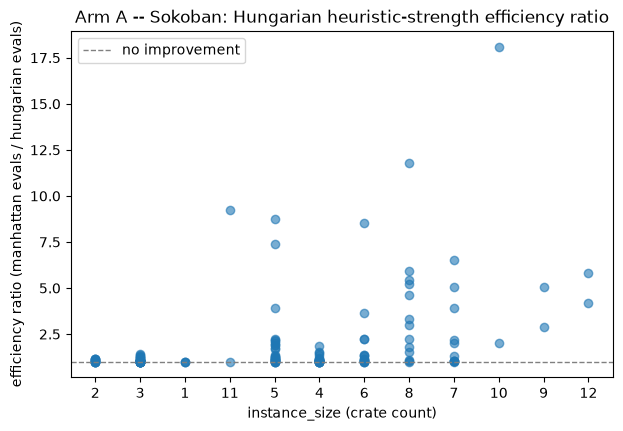

In [2]:
sokoban_ratios = arms.heuristic_strength_ratio(rows, domain="sokoban", weak_h="manhattan", tight_h="hungarian")
print(f"{len(sokoban_ratios)} Sokoban instances with both heuristics solved to equal (optimal) quality")

vals = [r["ratio"] for r in sokoban_ratios]
print(f"ratio: mean={statistics.mean(vals):.3f}  median={statistics.median(vals):.3f}  "
      f"min={min(vals):.3f}  max={max(vals):.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter([r["instance_size"] for r in sokoban_ratios], vals, alpha=0.6)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="no improvement")
ax.set_xlabel("instance_size (crate count)")
ax.set_ylabel("efficiency ratio (manhattan evals / hungarian evals)")
ax.set_title("Arm A -- Sokoban: Hungarian heuristic-strength efficiency ratio")
ax.legend()
plt.show()

### A note on the outlier(s)

The ratio distribution is right-skewed (median well below the mean) -- a handful of
instances get a *much* larger benefit from Hungarian than the typical map. That's
expected: Hungarian's advantage over Manhattan is proportional to how much goal
contention a specific map has (how often multiple crates are plausibly closest to
the same goal). Most maps have little contention; a few have a lot. Below are the
largest ratios, worth spot-checking individually rather than averaging away.

In [3]:
top = sorted(sokoban_ratios, key=lambda r: -r["ratio"])[:10]
for r in top:
    print(f"{r['instance_id']:<40} size={r['instance_size']:<4} ratio={r['ratio']:>6.2f}  "
          f"(manhattan={r['weak_evals']:>8.0f}, hungarian={r['tight_evals']:>8.0f})")

54-38_Sokoban-Cosmac-9-38                size=10   ratio= 18.10  (manhattan=   95737, hungarian=    5290)
39-20_Sokoban-Aruba5-20                  size=8    ratio= 11.80  (manhattan=   30253, hungarian=    2564)
3-7_Sokoban-Boxxle-2-7                   size=11   ratio=  9.24  (manhattan=   98382, hungarian=   10645)
31-25_Sokoban-Alberto-Garcia-25          size=5    ratio=  8.74  (manhattan=    3932, hungarian=     450)
test7                                    size=6    ratio=  8.51  (manhattan=     970, hungarian=     114)
test4                                    size=5    ratio=  7.37  (manhattan=     663, hungarian=      90)
44-75_Sokoban-Aruba10-75                 size=7    ratio=  6.55  (manhattan=   78605, hungarian=   12006)
44-61_Sokoban-Aruba10-61                 size=8    ratio=  5.93  (manhattan=  104747, hungarian=   17650)
56-84_Sokoban-Serena1-84                 size=12   ratio=  5.81  (manhattan=    1912, hungarian=     329)
52-7_Sokoban-Cosmac-7-7                  size=

## Arm A -- HP-lattice: weak vs. tight bound

HP's Branch-and-Bound (`src/protein-fold/bnb.py`) doesn't have a second,
independently literature-established heuristic the way Sokoban has Hungarian -- so
this arm's "weak" baseline was purpose-built as a genuinely weaker but still
*provably admissible* bound, using the same reasoning Manhattan vs. Hungarian
embodies: does resolving real-time contention beat ignoring it?

- **`bound="tight"`** (default): tracks each already-placed H monomer's *actual*
  remaining free lattice-neighbor count in real time (`po_free`/`pe_free`).
- **`bound="weak"`**: uses each monomer's *static structural* capacity instead
  (the maximum it could ever have, ignoring which neighbor cells are already
  occupied by other placed monomers).

Since true remaining capacity can never exceed the static structural maximum,
`weak >= tight` always (proof in `bnb.py`'s module docstring) -- both are
admissible, both prove the same optimum, so this is a legitimate equal-quality
comparison, not two different algorithms. Verified against a brute-force oracle
for both bound values (`tests/test_bnb.py`).

46 HP instances with both bounds solved to equal (optimal) quality
ratio: mean=1.103  median=1.022  min=1.000  max=1.567


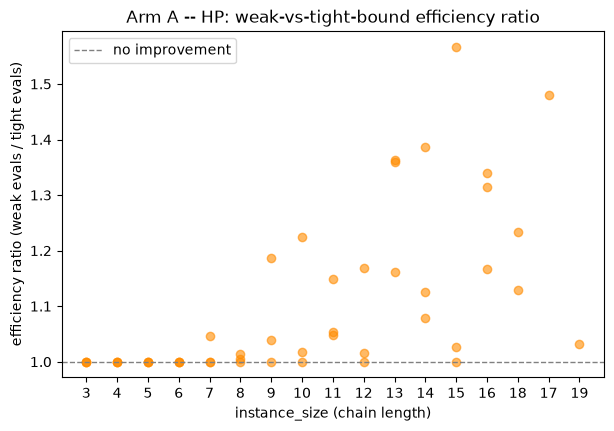

In [4]:
hp_ratios = arms.heuristic_strength_ratio(rows, domain="hp_lattice", weak_h="weak", tight_h="tight")
print(f"{len(hp_ratios)} HP instances with both bounds solved to equal (optimal) quality")

vals = [r["ratio"] for r in hp_ratios]
print(f"ratio: mean={statistics.mean(vals):.3f}  median={statistics.median(vals):.3f}  "
      f"min={min(vals):.3f}  max={max(vals):.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter([r["instance_size"] for r in hp_ratios], vals, alpha=0.6, color="darkorange")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="no improvement")
ax.set_xlabel("instance_size (chain length)")
ax.set_ylabel("efficiency ratio (weak evals / tight evals)")
ax.set_title("Arm A -- HP: weak-vs-tight-bound efficiency ratio")
ax.legend()
plt.show()

### Does heuristic strength transfer? -- comparing the two domains

Both ratios sit in a broadly similar range (compare the printed means/medians
above) -- a tighter, contention-resolving heuristic helps in both domains, and by
a comparable order of magnitude. That's real, if modest, evidence *for* transfer
on this specific technique. It's not proof: the two "tight" heuristics are built
differently enough (joint assignment-solving vs. real-time occupancy tracking)
that "heuristic strength helps" is the transferable claim, not any specific
heuristic construction.

## Arm B -- Sokoban: heuristic weight tuning (Pareto curve)

Weighted A* (`f = g + w*h`, `w > 1`) relaxes the admissibility bound to trade
solution optimality for search speed. Because quality now varies across the grid
(`w in {1.0, 1.25, 1.5, 2.0, 3.0, 5.0}`), a single scalar ratio would hide *which*
axis moved -- fewer evals could just mean a worse answer, not real efficiency
gain. That's why this arm reports a **Pareto curve** (evals vs. quality) per
instance instead.

**This arm is Sokoban-only.** `src/protein-fold/bnb.py` is a complete,
optimality-*proving* search by design (ADR 0002) -- giving it a `w`-style knob
would mean deliberately using an inadmissible bound, trading away the
completeness proof B&B was chosen for, with no equally-established literature
technique to anchor it the way Weighted A* (Pohl, 1970) anchors Sokoban's arm.
That asymmetry is itself a finding worth reporting: one technique transfers in
kind, the other doesn't have a natural analog in a different search paradigm.

155 Sokoban instances with a multi-point weight series
weight-grid sizes observed: [5, 6]


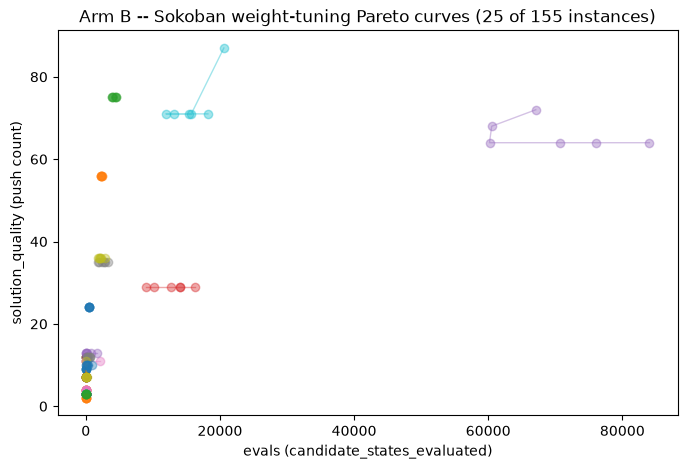

In [5]:
series = arms.arm_b_pareto(rows)
print(f"{len(series)} Sokoban instances with a multi-point weight series")
grid_sizes = sorted({len(s) for s in series.values()})
print(f"weight-grid sizes observed: {grid_sizes}")

fig, ax = plt.subplots(figsize=(8, 5))
for instance_id, s in list(series.items())[:25]:
    ax.plot([p["evals"] for p in s], [p["quality"] for p in s], marker="o", alpha=0.4, linewidth=1)
ax.set_xlabel("evals (candidate_states_evaluated)")
ax.set_ylabel("solution_quality (push count)")
ax.set_title(f"Arm B -- Sokoban weight-tuning Pareto curves ({min(25, len(series))} of {len(series)} instances)")
plt.show()

### A normalized view

Raw evals/quality are on totally different scales per instance (a 2-crate map and
a 12-crate map aren't comparable in absolute numbers), which makes the plot above
mostly useful for shape, not magnitude. Normalizing each instance's curve by its
own `w=1` baseline (evals and quality both divided by their `w=1` value) puts
every instance on the same axes, making the *aggregate* efficiency-vs-quality-loss
trend visible.

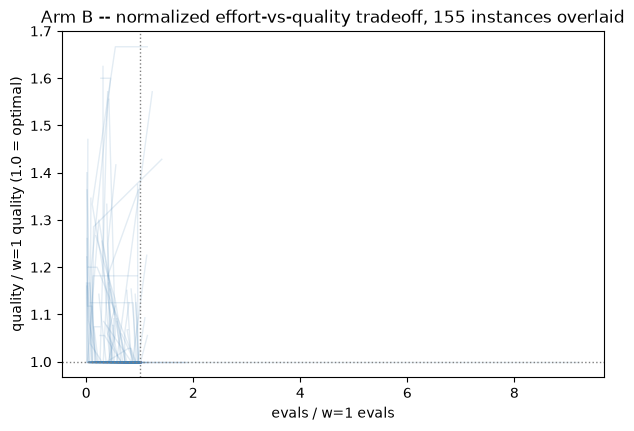

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
n_plotted = 0
for instance_id, s in series.items():
    base = next((p for p in s if p["w"] == 1.0), None)
    if base is None or base["evals"] == 0 or base["quality"] == 0:
        continue
    ax.plot(
        [p["evals"] / base["evals"] for p in s],
        [p["quality"] / base["quality"] for p in s],
        alpha=0.15, color="steelblue", linewidth=1,
    )
    n_plotted += 1
ax.set_xlabel("evals / w=1 evals")
ax.set_ylabel("quality / w=1 quality (1.0 = optimal)")
ax.set_title(f"Arm B -- normalized effort-vs-quality tradeoff, {n_plotted} instances overlaid")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.axvline(1.0, color="gray", linestyle=":", linewidth=1)
plt.show()

## Summary

- **Arm A transfers**: both domains show a real, similarly-sized efficiency gain
  from a tighter admissible heuristic (see the printed medians above), with a
  heavier tail of larger gains on contention-heavy/harder instances.
- **Arm B doesn't have an HP analog**, by design -- not a gap, a finding about
  how far "systematic search efficiency techniques" generalize across paradigms.
- Full technique rationale: `CONTEXT.md`, `docs/DECISIONS.md` (#9, #13),
  `docs/adr/0001-sokoban-search-algorithm.md`, `docs/adr/0002-hp-engine-bnb.md`.
- Regenerate the underlying data: `scripts/run_experiments.py` (Sokoban),
  `src/protein-fold/bnb_cli.py --bound {tight,weak}` (HP).